# Analysing alpha-values over different seeds

This notebook is used to gain insights into how varying alpha values changes the dynamics of the problem and influences decision making

It is structured as follows:
1) Initial setup, imports and loading of data
2) Demand patterns and state insight
3) Trip requests
3) Failed events hourly patterns
4) Vehicle activity decision insights and time allocation
5) Comparison of alpha values



# 1 Initial setup, imports and loading of data

In [ ]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import gzip
import json
import folium
import numpy as np

In [ ]:
# Loading paths to correct directories and files
current_path = Path(
    r"C:\Users\Minamsj\FOMOsim\policies\sjovik_sund\simulation_results\rough_estimates"
)
seed_path = Path(
    r"C:\Users\Minamsj\FOMOsim\policies\sjovik_sund\simulation_results\results_different_seeds"
)

if current_path.exists():
    results_dir_root = current_path
else:
    results_dir_root = seed_path

instance_path = r"C:\Users\Minamsj\FOMOsim\instances\TD_W34_old.json.gz"

# Configuration of alpha and seed values

alpha_value = 0.25  # <-- just change this
seed = 1            # <-- if change seed

# format alpha as in filenames, e.g. 0.300
alpha_str = f"{alpha_value:.3f}"


# Function to get result file based on kind and seed
def get_result_file(kind: str, seed: int = 1) -> Path:
    pattern = f"*fullweek_{alpha_str}_results_{kind}_seed_{seed}.csv"
    matches = list(results_dir_root.glob(pattern))
    
    if not matches:
        raise FileNotFoundError(f"No file found matching pattern: {pattern}")
    if len(matches) > 1:
        # If multiple, you could pick the newest; here we just warn and pick the first
        print(f"Warning: multiple files found for pattern {pattern}, using first:\n{matches[0]}")
    return matches[0]

# Load different data files
vehicle_df = pd.read_csv(get_result_file("vehicle_visits", seed=seed))
hourly_data = pd.read_csv(get_result_file("hourly", seed=seed))
station_hourly_activity_df = pd.read_csv(get_result_file("station_hourly", seed=seed))
trip_requests_df = pd.read_csv(get_result_file("trip_requests", seed=seed))

# Load the underlying station data for Trondheim instance
with gzip.open(instance_path, "rt") as f:
    data = json.load(f)

stations_df = pd.DataFrame(data["stations"])
stations_df[["lat", "lon"]] = stations_df["location"].apply(pd.Series)




In [ ]:
# values used in the plots and analysis
plt.rcParams.update({
    'figure.figsize': (16, 8),
})

value_size = 13
font_size = 15

## 1.1 State overview

In [ ]:
# Initial summary setup
alpha_summary = hourly_data.agg(
    {
        "Maintenance Time (minutes)": "sum",
        "Maintenance Violations": "sum",
        "Maintenance Starvations": "sum",
        "Bike Starvations": "sum",
        "Starvations": "sum",
        "Bike Pickups": "sum",
        "Bike Deliveries": "sum",
    }
).reset_index()

print(f"Alpha = {alpha_value} ({alpha_str})")
print(alpha_summary.to_string(index=False))

# pritn the file paths used
print("Files used:")
print(f"Vehicle visits: {get_result_file('vehicle_visits', seed=seed)}")
print(f"Hourly data: {get_result_file('hourly', seed=seed)}")   
print(f"Station hourly data: {get_result_file('station_hourly', seed=seed)}")   
print(f"Trip requests: {get_result_file('trip_requests', seed=seed)}")  

# 2 Demand patterns and state insight

In [ ]:
# print the instance path used
print(f"Instance used: {instance_path}")

# print number of stations, vehicles used, number of bikes
print(f"Number of vehicles in instance: {vehicle_df['Vehicle ID'].nunique()}")
print(f"Number of stations in instance: {len(stations_df)}")      


## 2.1 Average demand per hour for the simulation horizon

In [ ]:
import matplotlib.pyplot as plt

# 1. Count requests for each (Day, Hour) pair
demand_by_day_hour = (
    trip_requests_df.groupby(["Day", "Hour"])
    .size()
    .reset_index(name="Requests")
)

# 2. Compute mean requests per hour across days
mean_hourly_demand = (
    demand_by_day_hour.groupby("Hour")["Requests"]
    .mean()
    .reset_index()
)

hours = mean_hourly_demand["Hour"].tolist()
demand_vals = mean_hourly_demand["Requests"].tolist()

# Format x-axis labels as HH:00
hour_labels = [f"{int(h):02d}:00" for h in hours]

plt.figure()

bar_color = "#658354"   # change to whatever hex you want (e.g. "#ff5733")

plt.bar(hour_labels, demand_vals, color=bar_color, alpha=1.0)

plt.xlabel("Hour of Day")
plt.ylabel("Mean Trip Requests per Hour")

# Threshold for determining if bar is "too low"
threshold = 0.10 * max(demand_vals)

# Label values on bars
for h, v in zip(hour_labels, demand_vals):
    if v >= threshold:
        # Place label INSIDE the bar
        plt.text(h, v * 0.5,
                 f"{v:.1f}",
                 ha='center', va='center',
                 color='white', fontsize=value_size-1, fontweight='bold')
    else:
        # Place label ABOVE the bar
        plt.text(h, v + threshold * 0.1,
                 f"{v:.1f}",
                 ha='center', va='bottom',
                 color='black', fontsize=value_size-1)

plt.yticks(fontsize=font_size)
plt.xticks(rotation=45, fontsize=font_size)
plt.grid(axis='both', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()


## 2.2 Demand across all hours

In [ ]:

# --------------------------------------------------------
# 1. Count trip requests for each (Day, Hour) pair
# --------------------------------------------------------
demand_by_day_hour = (
    trip_requests_df.groupby(["Day", "Hour"])
    .size()
    .reset_index(name="Requests")
)

# Ensure sorting (important for correct x-axis order)
demand_by_day_hour = demand_by_day_hour.sort_values(["Day", "Hour"])

# --------------------------------------------------------
# 2. Prepare flattened index for plotting
# --------------------------------------------------------
# Create a unique index for each Day-Hour combination
demand_by_day_hour["DayHourIndex"] = (
    demand_by_day_hour["Day"] * 24 + demand_by_day_hour["Hour"]
)

x = demand_by_day_hour["DayHourIndex"]
y = demand_by_day_hour["Requests"]

# Bottom x-axis label = hour
hour_labels = [f"{h:02d}:00" for h in demand_by_day_hour["Hour"]]

# Top x-axis labels = day
day_ticks = (
    demand_by_day_hour.groupby("Day")["DayHourIndex"]
    .min()
    .values
)
day_labels = [f"Day {d}" for d in demand_by_day_hour["Day"].unique()]

# --------------------------------------------------------
# 3. Plot
# --------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(20,6))

bar_color = "#658354"

ax1.bar(x, y, width=0.9, color=bar_color)

ax1.set_ylabel("Trip Requests", fontsize=14)
ax1.set_xlabel("Hour of Day", fontsize=14)

# Bottom axis → hours
ax1.set_xticks(x[::1])   # show every hour
ax1.set_xticklabels(hour_labels, rotation=90, fontsize=10)

# --------------------------------------------------------
# 4. Add top axis → days
# --------------------------------------------------------
ax2 = ax1.twiny()

# align top axis with bottom axis
ax2.set_xlim(ax1.get_xlim())

ax2.set_xticks(day_ticks)
ax2.set_xticklabels(day_labels, fontsize=12, fontweight="bold")

ax2.set_xlabel("Day", fontsize=14)

# --------------------------------------------------------
# 5. Optional styling
# --------------------------------------------------------
ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.title("Trip Requests by Day and Hour", fontsize=16)
plt.tight_layout()
plt.show()


# 3 Trip requests and fleet aspects

## 3.1 Average fleet criticality

### 3.1.1 Line plot during the day

In [ ]:

crit = hourly_data.groupby(["Day", "Hour"], as_index=False)["Avg Bike Criticality"].mean()

window = 3
crit["MA"] = crit["Avg Bike Criticality"].rolling(window=window, min_periods=1).mean()

# Hour-level labels for bottom axis
crit["hour_label"] = crit["Hour"].astype(int).astype(str).str.zfill(2) + ":00"

# Optional: if you still want combined labels, keep this too:
crit["label"] = (
    "D" + crit["Day"].astype(str)
    + " " + crit["Hour"].astype(str).str.zfill(2) + ":00"
)

# Use simple integer x-axis for plotting
x = range(len(crit))

# indices where a new day starts
day_change_idx = crit.index[crit["Day"].ne(crit["Day"].shift())].tolist()
# positions where a vertical line goes (between days)
boundary_positions = [i for i in day_change_idx[1:]]  # skip first (day 1 start)

# centers for each day (for day labels on 2nd axis)
day_centers = []
day_labels = []
for day_val in crit["Day"].unique():
    idxs = crit.index[crit["Day"] == day_val]
    start_i, end_i = idxs[0], idxs[-1]
    center = (start_i + end_i) / 2
    day_centers.append(center)
    day_labels.append(f"Day {int(day_val)}")

# ===================== PLOTTING ====================
fig, ax = plt.subplots(figsize=(16, 6))

line_color = "#658354"

# Raw values
ax.plot(x, crit["Avg Bike Criticality"], alpha=0.3,
        label="Raw criticality", color=line_color)

# Moving average
ax.plot(x, crit["MA"], linewidth=3, color=line_color,
        label=f"Moving average ({window}h)")

# Vertical lines between days
for pos in boundary_positions:
    ax.axvline(x=pos - 0.5, color="gray", linestyle="--",
               linewidth=1, alpha=0.6)

ax.set_ylabel("Average Fleet Criticality", fontsize=15)
ax.set_xlabel("", fontsize=15)

# === BOTTOM AXIS: HOURS ===
step = 3 if len(crit) > 10 else 1
ax.set_xticks([i for i in x][::step])
ax.set_xticklabels(crit["hour_label"].iloc[::step],
                   rotation=45, ha="right", fontsize=12)

ax.tick_params(axis='y', labelsize=13)

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())  # share the same x-limits

ax2.set_xticks(day_centers)
ax2.set_xticklabels(day_labels, fontsize=13)

ax2.xaxis.set_ticks_position("top")
ax2.xaxis.set_label_position("top")
ax2.set_xlabel("", fontsize=15)

ax.legend()
fig.tight_layout()
plt.show()


### 3.1.2 Map showing average criticality of all stations

In [ ]:

# Extract numeric station id from "S0", "S1", ...
station_hourly_activity_df["id"] = (
    station_hourly_activity_df["Station ID"]
    .astype(str)
    .str.extract(r"S(\d+)")
    .astype(int)
)

# --- Compute per-row share of capacity that is broken ---
# guard against capacity = 0 just in case
station_hourly_activity_df["broken_share"] = (
    station_hourly_activity_df["Unusable Bikes"] /
    station_hourly_activity_df["Capacity"].replace(0, np.nan)
)

# ---------------------------
# Average maintenance criticality AND avg % broken per station
# ---------------------------
crit_per_station = (
    station_hourly_activity_df
    .groupby("id", as_index=False)
    .agg(
        avg_maint_crit=("Avg Maintenance Criticality", "mean"),
        avg_broken_share=("broken_share", "mean")   # this is 0–1
    )
)

# Merge with coordinates from stations_df (must already have lat/lon)
stations_crit = stations_df.merge(crit_per_station, on="id", how="left")
stations_crit["avg_maint_crit"] = stations_crit["avg_maint_crit"].fillna(0.0)
stations_crit["avg_broken_share"] = stations_crit["avg_broken_share"].fillna(0.0)

center_lat = stations_crit["lat"].mean()
center_lon = stations_crit["lon"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

# simple color mapping based on maintenance criticality
def crit_color(c):
    if c >= 0.6:
        return "red"
    elif c >= 0.5:
        return "orange"
    elif c >= 0.4:
        return "yellow"
    else:
        return "green"

for _, row in stations_crit.iterrows():
    c = row["avg_maint_crit"]
    broken_pct = row["avg_broken_share"] * 100  # turn into %

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6,  # could also scale with broken_pct if you like
        fill=True,
        fill_opacity=0.8,
        color=crit_color(c),
        fill_color=crit_color(c),
        popup=(
            f"Station S{row['id']}<br>"
            f"Avg maint. criticality: {c:.3f}<br>"
            f"Avg broken: {broken_pct:.1f}% of capacity"
        ),
    ).add_to(m)

m.save(f"station_criticality_map_S{seed}_A{alpha_value}.html")


## 3.2 Service rate computation

In [ ]:
# --- Existing: per-station requests & successes ---
trip_requests_counts = (
    trip_requests_df["Station ID"]
    .value_counts()
    .reset_index()
)
trip_requests_counts.columns = ["Station ID", "num_requests"]
print("Number of requests:", trip_requests_counts["num_requests"].sum())

trip_requests_df["successful_trip"] = trip_requests_df["Failure Reason"].isna()

successful_trip_counts = (
    trip_requests_df[trip_requests_df["successful_trip"]]
    .groupby("Station ID")
    .size()
    .reset_index(name="num_successful_trips")
)

trip_summary = trip_requests_counts.merge(
    successful_trip_counts, on="Station ID", how="left"
)
trip_summary["num_successful_trips"] = (
    trip_summary["num_successful_trips"].fillna(0).astype(int)
)

congestion_col = "Long Congestions"   # column in hourly_data

# total long congestions in the whole system
total_long_congestions = hourly_data[congestion_col].sum()

# total successful trips in the whole system
total_successful = trip_requests_df["successful_trip"].sum()

# subtract congestion from successful
effective_total_successful = max(
    total_successful - total_long_congestions, 0
)

total_requests = len(trip_requests_df)

service_rate_system = (
    effective_total_successful / total_requests if total_requests > 0 else 0
)

print(f"Total Long Congestions: {total_long_congestions}")
print(f"Effective successful trips: {effective_total_successful}")
print(f"Service rate (adjusted): {service_rate_system:.2%}")


# 4 Failed events

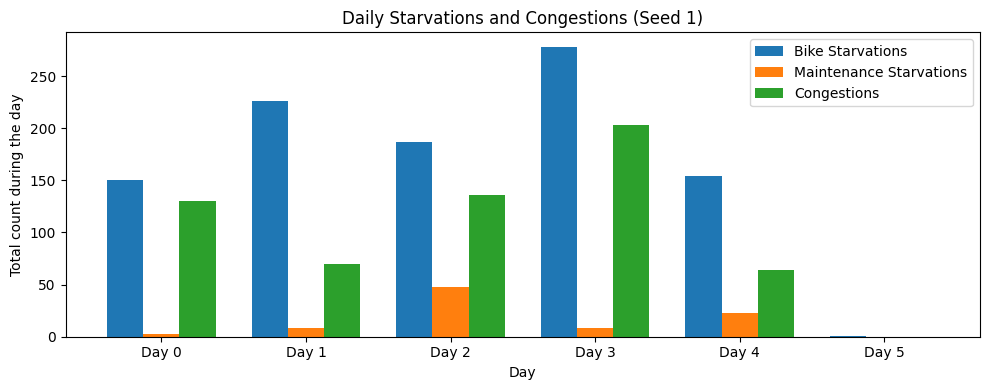

In [66]:
daily = ( hourly_data.groupby(["Seed", "Day"]) 
         .agg({ "Bike Starvations": "sum", "Long Congestions": "sum", "Short Congestions": "sum", "Maintenance Starvations": "sum" }) 
         .reset_index() ) # Total congestions per day 

daily["Congestions"] = daily["Long Congestions"]

# === PLOT PER SEED: 3 bars side-by-side per DAY ===
for seed, g in daily.groupby("Seed"):
    
    # DAY (unique days only)
    days = g["Day"].values
    
    bike_starv  = g["Bike Starvations"].values
    maint_starv = g["Maintenance Starvations"].values
    cong        = g["Long Congestions"].values #+ g["Short Congestions"].values
    
    x = np.arange(len(days))   # 0,1,2,... positions
    width = 0.25               # narrower bars

    plt.figure(figsize=(10,4))

    plt.bar(x - width, bike_starv,  width=width, label="Bike Starvations")
    plt.bar(x,         maint_starv, width=width, label="Maintenance Starvations")
    plt.bar(x + width, cong,        width=width, label="Congestions")

    plt.xlabel("Day")
    plt.ylabel("Total count during the day")
    plt.title(f"Daily Starvations and Congestions (Seed {seed})")

    plt.xticks(x, [f"Day {d}" for d in days])
    plt.legend()
    plt.tight_layout()
    plt.show()


## 4.1 Bike starvation

### 4.1.1 Plot for mean over all hours of simulation horizon

In [ ]:
# 1. Sum maintenance starvations for each (Day, Hour) pair
starv_by_day_hour = (
    hourly_data.groupby(["Day", "Hour"])["Bike Starvations"]
    .sum()
    .reset_index()
)

# 2. Compute mean maintenance starvations per hour across days
mean_hourly_starv = (
    starv_by_day_hour.groupby("Hour")["Bike Starvations"]
    .mean()
    .reset_index()
)

# Extract hours and mean values
hours = mean_hourly_starv["Hour"].tolist()
starv_vals = mean_hourly_starv["Bike Starvations"].tolist()

# Convert numeric hours to "HH:00"
hour_labels = [f"{int(h):02d}:00" for h in hours]

# 3. Create plot
plt.figure()

# Bar plot
bar_color = "#658354"    # Matplotlib default blue
plt.bar(hour_labels, starv_vals, color=bar_color, alpha=1.0)

# Line plot overlay
#plt.plot(hour_labels, starv_vals, marker='o')

# Labels and title
plt.xlabel("Hour of Day", fontsize=font_size)
plt.ylabel("Mean Bike Starvations", fontsize=font_size)


threshold = 0.10 * max(starv_vals)

# Label values on bars
for h, v in zip(hour_labels, starv_vals):
    if v != 0.0:
        if v >= threshold:
            # Place label INSIDE the bar
            plt.text(h, v * 0.5,
                    f"{v:.1f}",
                    ha='center', va='center',
                    color='white', fontsize=value_size, fontweight='bold')
        else:
            # Place label ABOVE the bar
            plt.text(h, v + threshold * 0.1,
                    f"{v:.1f}",
                    ha='center', va='bottom',
                    color='black', fontsize=value_size)

plt.xticks(rotation=45, fontsize=font_size)
plt.yticks(fontsize=font_size)
plt.grid(axis='both', linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()


## 4.2 Congestion

### 4.2.1 Plot mean over all hours of simulation horizon (24h agg)

In [ ]:
# 1. Sum maintenance starvations for each (Day, Hour) pair
starv_by_day_hour = (
    hourly_data.groupby(["Day", "Hour"])["Long Congestions"]
    .sum()
    .reset_index()
)

# 2. Compute mean maintenance starvations per hour across days
mean_hourly_cong = (
    starv_by_day_hour.groupby("Hour")["Long Congestions"]
    .mean()
    .reset_index()
)

# Extract hours and mean values
hours = mean_hourly_cong["Hour"].tolist()
starv_vals = mean_hourly_cong["Long Congestions"].tolist()

# Convert numeric hours to "HH:00"
hour_labels = [f"{int(h):02d}:00" for h in hours]

# 3. Create plot
plt.figure()

# Bar plot
bar_color = "#658354"    # Matplotlib default blue
plt.bar(hour_labels, starv_vals, color=bar_color, alpha=1.0)

# Line plot overlay
#plt.plot(hour_labels, starv_vals, marker='o')

# Labels and title
plt.xlabel("Hour of Day", fontsize=font_size)
plt.ylabel("Mean Congestions", fontsize=font_size)


threshold = 0.10 * max(starv_vals)

# Label values on bars
for h, v in zip(hour_labels, starv_vals):
    if v != 0.0:
        if v >= threshold:
            # Place label INSIDE the bar
            plt.text(h, v * 0.5,
                    f"{v:.1f}",
                    ha='center', va='center',
                    color='white', fontsize=value_size, fontweight='bold')
        else:
            # Place label ABOVE the bar
            plt.text(h, v + threshold * 0.1,
                    f"{v:.1f}",
                    ha='center', va='bottom',
                    color='black', fontsize=value_size)

plt.xticks(rotation=45, fontsize=font_size)
plt.yticks(fontsize=font_size)
plt.grid(axis='both', linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()

### 4.2.2 XX

# 4.3 Maintenance violations

## 4.4 Maintenance starvations

### 4.4.1 Accumulated for different parts of day

In [ ]:
# Define which hours count as "morning" and "afternoon"
# Adjust these sets to match your thesis definition
morning_hours   = [7, 8, 9, 10]       # example: 07:00–11:00
early_mid_day_hours  = [11, 12]    # example: 11:00–15:00
late_mid_day_hours  = [13, 14]    # example: 11:00–15:00
afternoon_hours = [15, 16, 17, 18]    # example: 15:00–19:00
evening_hours   = [19, 20, 21, 22]    # example: 19:00–23:00

# Aggregate maintenance starvations by hour of day (across all days)
maint_by_hour = (
    hourly_data
    .groupby("Hour")["Maintenance Starvations"]
    .sum()
    .rename("MaintStarvations")
)

morning_maint   = maint_by_hour.loc[morning_hours].sum()
early_mid_day_maint   = maint_by_hour.loc[early_mid_day_hours].sum()
late_mid_day_maint   = maint_by_hour.loc[late_mid_day_hours].sum()
afternoon_maint = maint_by_hour.loc[afternoon_hours].sum()
evening_maint   = maint_by_hour.loc[evening_hours].sum()


if afternoon_maint > 0:
    ratio = morning_maint / afternoon_maint
else:
    ratio = np.nan

print("Morning maintenance starvations:", morning_maint)
print("Early mid-day maintenance starvations:", early_mid_day_maint)
print("Late mid-day maintenance starvations:", late_mid_day_maint)
print("Afternoon maintenance starvations:", afternoon_maint)
print("Evening maintenance starvations:", evening_maint)
print("Ratio (morning / afternoon):", ratio)

### 4.4.2 Plot for mean over all hours of simulation horizon

In [ ]:
# 1. Sum maintenance starvations for each (Day, Hour) pair
maint_by_day_hour = (
    hourly_data.groupby(["Day", "Hour"])["Maintenance Starvations"]
    .sum()
    .reset_index()
)

# 2. Compute mean maintenance starvations per hour across days
mean_hourly_maint = (
    maint_by_day_hour.groupby("Hour")["Maintenance Starvations"]
    .mean()
    .reset_index()
)

# Extract hours and mean values
hours = mean_hourly_maint["Hour"].tolist()
maint_vals = mean_hourly_maint["Maintenance Starvations"].tolist()

# Convert numeric hours to "HH:00"
hour_labels = [f"{int(h):02d}:00" for h in hours]

# 3. Create plot
plt.figure()

# Bar plot
bar_color = "#658354"    # Matplotlib default blue
plt.bar(hour_labels, maint_vals, color=bar_color, alpha=1.0, width=0.9)

# Line plot overlay
#plt.plot(hour_labels, maint_vals, marker='o')

# Labels and title
plt.xlabel("Hour of Day", fontsize=font_size)
plt.ylabel("Mean Maintenance Starvations", fontsize=font_size)

# Value labels above bars
for h, v in zip(hour_labels, maint_vals):
    if v != 0.0:
        plt.text(h, v * 0.5,        # halfway up the bar
                 f"{v:.2f}",
                 ha='center', va='center', color='white', fontsize=value_size,  fontweight='bold')

plt.yticks(fontsize=font_size)
plt.xticks(rotation=45, fontsize=font_size)
plt.grid(axis='both', linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()


### 4.4.3 XXXXX 

# 5 Vehicle insight

In [ ]:
# print the total number of visitns for vehicles and how many unique stations were visited
total_visits = vehicle_df.shape[0]
unique_stations = vehicle_df["Station ID"].nunique()
print(f"Total visits: {total_visits}, Unique stations visited: {unique_stations}")


In [ ]:
# Extract numeric id: "S35" → 35
vehicle_df["id"] = vehicle_df["Station ID"].str.extract(r"S(\d+)").astype(int)

# Count visits per station id
station_counts = (
    vehicle_df
        .groupby("id")
        .size()
        .reset_index(name="num_visits")
)

# Join on integer id
stations_with_visits = stations_df.merge(station_counts, on="id", how="left")

# Fill stations that never appear in visits
stations_with_visits["num_visits"] = stations_with_visits["num_visits"].fillna(0).astype(int)

stations_with_visits.head(70)


## 5.1 Unique stations visited per hour

In [ ]:
df = vehicle_df  # your visit data

# Count visits per station per hour
visits_matrix = (
    df.groupby(["Station ID", "Hour"])
      .size()
      .reset_index(name="visits")
)

# Pivot to station x hour matrix
heatmap_data = visits_matrix.pivot(index="Station ID", columns="Hour", values="visits")

# Replace NaN with 0
heatmap_data = heatmap_data.fillna(0)

plt.figure(figsize=(16,10))
sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.01,
    cbar_kws={"label": "Number of Visits"}
)

plt.xlabel("Hour of Day", fontsize=14)
plt.ylabel("Station ID", fontsize=14)
plt.title("Heatmap of Station Visits by Hour", fontsize=16)

plt.xticks()
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

## 5.2 Plot over visit frequency on map

In [ ]:
def visit_color(n):
    if n == 0:
        return "light green"
    elif 1 <= n <= 5:
        return "#f7f148"
    elif 6 <= n <= 15:
        return "#f3903f"
    elif 16 <= n <= 25:
        return "#ed683c"
    else:
        return "#ce0011"




# Center map on mean lat/lon of all stations
center_lat = stations_with_visits["lat"].mean()
center_lon = stations_with_visits["lon"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

# (optional) show all stations, or only top N
#top_stations = stations_with_visits.sort_values("num_visits", ascending=False).head(50)
top_stations = stations_with_visits  # <- all
print(top_stations["num_visits"].head(70))

max_visits = top_stations["num_visits"].max()
min_radius = 5
max_radius = 20 if max_visits > 0 else 6

for _, row in top_stations.iterrows():
    n = row["num_visits"]
    # scale radius with visits, but keep within a nice range
    radius = min_radius if max_visits == 0 else (
        min_radius + (n / max_visits) * (max_radius - min_radius)
    )

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=radius,
        fill=True,
        color=visit_color(n),
        fill_color=visit_color(n),
        fill_opacity=0.8,
        popup=f"Station S{row['id']}<br>Visits: {n}",
    ).add_to(m)

m.save(f"trondheim_map_S{seed}_A{alpha_value}.html")

## 5.3 Vehicle maintenance allocation

In [ ]:
hourly_data = hourly_data.sort_values(["Seed", "Time (minutes)"])

# === MOVING AVERAGE, per seed (3-hour window since data is hourly) ===
def add_ma(group):
    m = group["Maintenance Time (minutes)"]
    group["Maintenance_MA"] = m.rolling(window=3, min_periods=1).mean()
    return group

hourly_data = hourly_data.groupby("Seed", group_keys=False).apply(add_ma)

# === HUMAN-READABLE LABELS: "Day d HH:00" ===
hourly_data["label"] = (
    "Day " + hourly_data["Day"].astype(str)
    + " " + hourly_data["Hour"].astype(str).str.zfill(2) + ":00"
)

# === PLOT FOR EACH SEED ===
for seed, g in hourly_data.groupby("Seed"):

    x = g["Time (minutes)"]  # numeric x-axis

    plt.figure(figsize=(12, 4))
    plt.plot(x, g["Maintenance Time (minutes)"], alpha=0.4, label="hourly")
    plt.plot(x, g["Maintenance_MA"], linewidth=2, label="moving average (3h)")

    plt.ylabel("Maintenance time (minutes)")
    plt.xlabel("Simulation time")
    plt.title(f"Maintenance workload over time (Seed {seed})")

    # x-axis labels every 3rd point (avoid clutter)
    step = 3
    xticks = x.iloc[::step]
    xlabels = g["label"].iloc[::step]
    plt.xticks(xticks, xlabels, rotation=45, ha="right")

    plt.legend()
    plt.tight_layout()
    plt.show()